# 02 — Feature Engineering

Computes 11 technical indicators per stock, creates classification and regression labels, normalizes per stock, and saves to `data/features/`.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

BASE_DIR     = "."
RAW_DIR      = os.path.join(BASE_DIR, "data/raw")
FEAT_DIR     = os.path.join(BASE_DIR, "data/features")

TICKERS      = ["AAPL", "MSFT", "JPM", "GS", "JNJ", "PFE", "SPOT", "AMZN", "TSLA"]
FEATURE_COLS = [
    "SMA_5", "SMA_10", "SMA_20",
    "EMA_5", "EMA_10", "EMA_20",
    "RSI_14", "MACD", "MACD_Signal",
    "Volatility", "Volume_Change"
]

os.makedirs(FEAT_DIR, exist_ok=True)
print("Imports done.")

Matplotlib is building the font cache; this may take a moment.


Imports done.


## 1. Indicator functions

In [2]:
def compute_sma(close, window):
    return close.rolling(window=window).mean()

def compute_ema(close, window):
    return close.ewm(span=window, adjust=False).mean()

def compute_rsi(close, window=14):
    delta    = close.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(close, fast=12, slow=26, signal=9):
    ema_fast    = close.ewm(span=fast, adjust=False).mean()
    ema_slow    = close.ewm(span=slow, adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return pd.DataFrame({"MACD": macd_line, "MACD_Signal": signal_line})

def compute_volatility(close, window=10):
    log_returns = np.log(close / close.shift(1))
    return log_returns.rolling(window=window).std()

def compute_volume_change(volume):
    return volume.pct_change()

print("Feature functions defined.")

Feature functions defined.


## 2. Compute features and labels

In [3]:
all_dfs = []

for ticker in TICKERS:
    path = os.path.join(RAW_DIR, f"{ticker}.csv")
    df   = pd.read_csv(path, index_col="Date", parse_dates=True).sort_index()

    close  = df["Close"]
    volume = df["Volume"]

    df["SMA_5"]         = compute_sma(close, 5)
    df["SMA_10"]        = compute_sma(close, 10)
    df["SMA_20"]        = compute_sma(close, 20)
    df["EMA_5"]         = compute_ema(close, 5)
    df["EMA_10"]        = compute_ema(close, 10)
    df["EMA_20"]        = compute_ema(close, 20)
    df["RSI_14"]        = compute_rsi(close, 14)
    macd_df             = compute_macd(close)
    df["MACD"]          = macd_df["MACD"]
    df["MACD_Signal"]   = macd_df["MACD_Signal"]
    df["Volatility"]    = compute_volatility(close, 10)
    df["Volume_Change"] = compute_volume_change(volume)

    # next day's close > today = 1, else 0
    df["Label_Class"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
    # next day percentage return
    df["Label_Reg"]   = (df["Close"].shift(-1) - df["Close"]) / df["Close"]

    df["Ticker"] = ticker
    all_dfs.append(df)
    print(f"{ticker}  shape before cleaning: {df.shape}")

combined = pd.concat(all_dfs, axis=0)
print(f"Combined shape before dropping NaNs: {combined.shape}")

AAPL  shape before cleaning: (1332, 19)
MSFT  shape before cleaning: (1332, 19)
JPM  shape before cleaning: (1332, 19)
GS  shape before cleaning: (1332, 19)
JNJ  shape before cleaning: (1332, 19)
PFE  shape before cleaning: (1332, 19)
SPOT  shape before cleaning: (1332, 19)
AMZN  shape before cleaning: (1332, 19)
TSLA  shape before cleaning: (1332, 19)
Combined shape before dropping NaNs: (11988, 19)


## 3. Drop NaN rows

NaNs come from indicator warm-up (MACD needs 26 rows) and the last row of each stock which has no next-day label.

In [4]:
before = len(combined)
combined.dropna(inplace=True)
after  = len(combined)
print(f"Rows before: {before:,}  after: {after:,}  dropped: {before - after:,}")

Rows before: 11,988  after: 11,808  dropped: 180


## 4. Normalize per stock

StandardScaler applied per stock independently. Global normalization would let AAPL's price level contaminate TSLA's indicator scales.

In [5]:
scaled_parts = []

for ticker in TICKERS:
    mask   = combined["Ticker"] == ticker
    subset = combined.loc[mask, FEATURE_COLS].copy()

    scaler      = StandardScaler()
    scaled_vals = scaler.fit_transform(subset)
    scaled_df   = pd.DataFrame(scaled_vals, index=subset.index, columns=FEATURE_COLS)
    scaled_parts.append(scaled_df)

combined_scaled               = combined.copy()
combined_scaled[FEATURE_COLS] = pd.concat(scaled_parts).reindex(combined.index)

print(f"Normalization complete. Shape: {combined_scaled[FEATURE_COLS].shape}")

Normalization complete. Shape: (11808, 11)


## 5. Label balance check

In [6]:
print(f"{'Ticker':<7} {'UP':>6} {'DOWN':>6} {'% UP':>8}")
print("-" * 32)
for ticker in TICKERS:
    mask   = combined_scaled["Ticker"] == ticker
    counts = combined_scaled.loc[mask, "Label_Class"].value_counts()
    total  = counts.sum()
    pct_up = counts.get(1, 0) / total * 100
    print(f"{ticker:<7} {counts.get(1,0):>6} {counts.get(0,0):>6} {pct_up:>7.1f}%")

overall = combined_scaled["Label_Class"].value_counts()
print("-" * 32)
print(f"{'TOTAL':<7} {overall.get(1,0):>6} {overall.get(0,0):>6} "
      f"{overall.get(1,0)/len(combined_scaled)*100:>7.1f}%")

Ticker      UP   DOWN     % UP
--------------------------------
AAPL       693    619    52.8%
MSFT       678    634    51.7%
JPM        706    606    53.8%
GS         697    615    53.1%
JNJ        679    633    51.8%
PFE        633    679    48.2%
SPOT       679    633    51.8%
AMZN       678    634    51.7%
TSLA       673    639    51.3%
--------------------------------
TOTAL     6116   5692    51.8%


## 6. Save

In [7]:
combined_scaled.to_csv(os.path.join(FEAT_DIR, "features_all.csv"))

for ticker in TICKERS:
    mask = combined_scaled["Ticker"] == ticker
    combined_scaled[mask].to_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"))

print("Saved files:")
for f in sorted(os.listdir(FEAT_DIR)):
    size = os.path.getsize(os.path.join(FEAT_DIR, f))
    print(f"  {f:<35}  {size/1024:.1f} KB")
print("Notebook 02 complete — features saved to data/features/")

Saved files:
  AAPL_features.csv                    434.2 KB
  AMZN_features.csv                    429.8 KB
  GS_features.csv                      428.4 KB
  JNJ_features.csv                     435.5 KB
  JPM_features.csv                     432.0 KB
  MSFT_features.csv                    431.6 KB
  PFE_features.csv                     432.0 KB
  SPOT_features.csv                    424.1 KB
  TSLA_features.csv                    428.7 KB
  features_all.csv                     3875.1 KB
Notebook 02 complete — features saved to data/features/


## 7. Plot features for AAPL (optional)

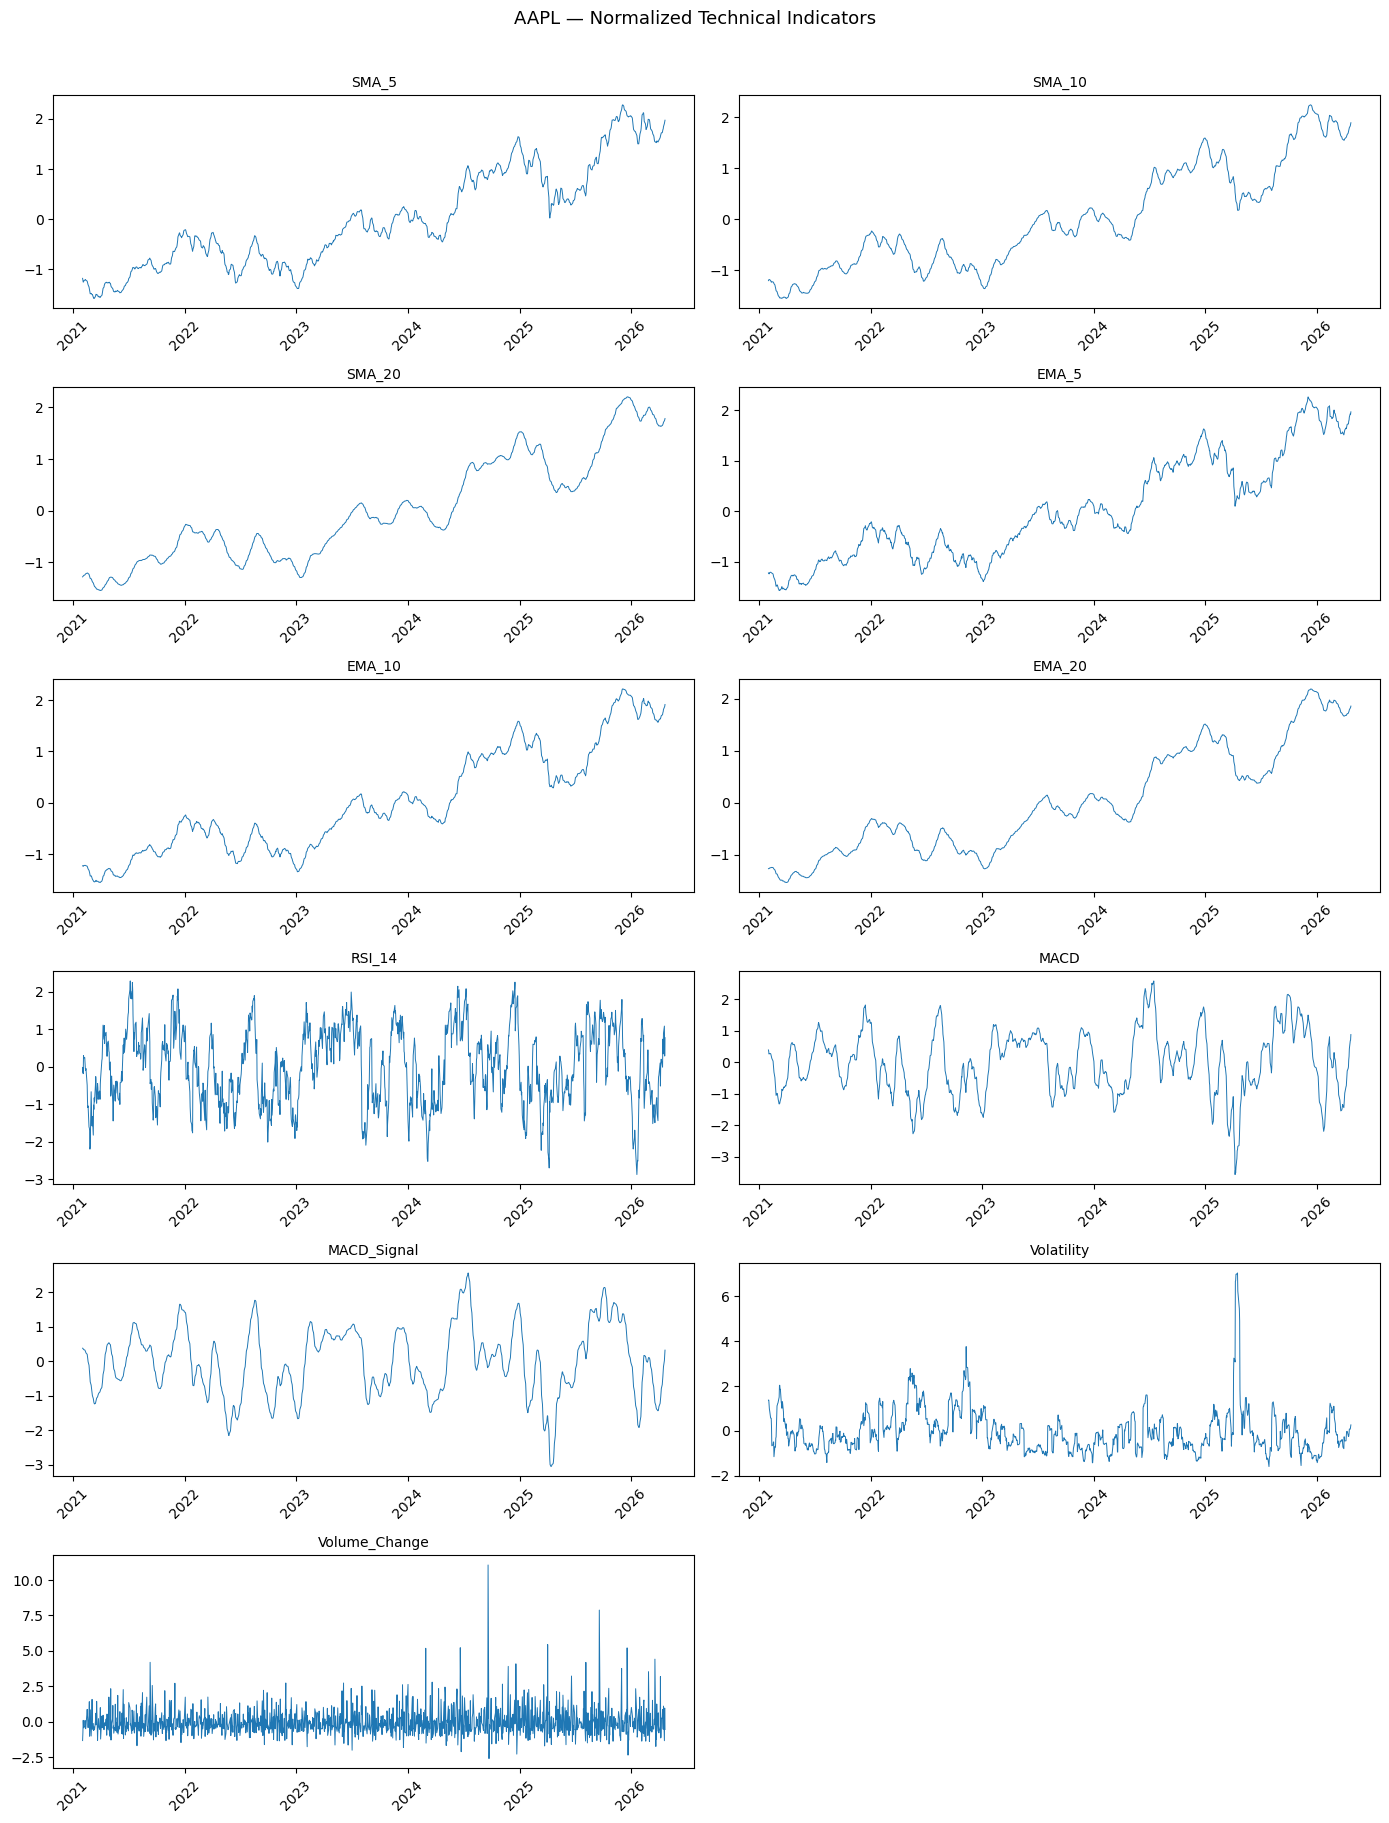

In [8]:
sample = combined_scaled[combined_scaled["Ticker"] == "AAPL"][FEATURE_COLS]

fig, axes = plt.subplots(6, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].plot(sample.index, sample[col], linewidth=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=45)

axes[-1].set_visible(False)
plt.suptitle("AAPL — Normalized Technical Indicators", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FEAT_DIR, "aapl_features_plot.png"), dpi=120, bbox_inches="tight")
plt.show()